In [1]:
import sys
sys.path.append('/home/caoren/tmp/PIRC_for_HigherOrderCausality')
import os
os.chdir("/home/caoren/tmp/PIRC_for_HigherOrderCausality/Results2/Lorenz")
import numpy as np
from Data_gen import *
from Torch_Library import *
from PIRC import PIRC_flatten as Nonliear_PIRC
# lots of parameter combinations that you can choose. THe auc is 1 and prediction is low enough
# {'n_units': 10, 'alpha': 0.4, 'sigma_in': 0.30000000000000004, 'rho': 1.0, 'tikh': 1.0}
# {'n_units': 10, 'alpha': 0.7000000000000001, 'sigma_in': 0.2, 'rho': 0.1, 'tikh': 1.0}
# {'n_units': 10, 'alpha': 0.7000000000000001, 'sigma_in': 0.2, 'rho': 0.1, 'tikh': 1.0}

/home/caoren/anaconda3/envs/pytorch/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# def Win_Fixed_Wres(
#     ExpandNodes,
#     n_units,
#     device,
#     block_dim=1,
#     connectivity=1.0
# ):
#     if connectivity == 1.0:
#         Win = 2 * torch.rand(
#             ExpandNodes, block_dim, n_units,
#             device=device
#         ) - 1
#
#         Wres = torch.empty(
#             n_units, n_units,
#             device=device
#         ).uniform_(-1, 1)
#     elif connectivity == 0.5:
#         n1 = n_units // 2
#         Wres = torch.zeros(
#             n_units, n_units,
#             device=device
#         )
#         Wres[:n1, :n1].uniform_(-1, 1)
#         Wres[n1:, n1:].uniform_(-1, 1)
#         d1 = block_dim // 2
#         Win = torch.zeros(
#             ExpandNodes, block_dim, n_units,
#             device=device
#         )
#         Win[:, :d1, :n1].uniform_(-1, 1)
#         Win[:, d1:, n1:].uniform_(-1, 1)
#     return Win, Wres
def Win_Fixed_Wres(
    ExpandNodes,
    n_units,
    device,
    block_dim=1,
    connectivity=1.0
):
    if connectivity == 1.0:
        Win = torch.zeros(
            ExpandNodes, block_dim, n_units,
            device=device
        )
        # 只生成一套非零位置
        idx = torch.randint(
            0, block_dim,
            (1, 1, n_units),
            device=device
        )
        # 所有 ExpandNodes 使用相同位置
        idx = idx.expand(ExpandNodes, -1, -1)
        # 但非零值可以各自随机
        values = 2 * torch.rand(
            ExpandNodes, 1, n_units,
            device=device
        ) - 1
        Win.scatter_(1, idx, values)
        Wres = torch.empty(
            n_units, n_units,
            device=device
        ).uniform_(-1, 1)
    if connectivity == -1.0:
        Win = torch.zeros(
            ExpandNodes, block_dim, n_units,
            device=device
        )

        # 每一列随机选择一个非零位置
        idx = torch.randint(
            0, block_dim,
            (ExpandNodes, 1, n_units),
            device=device
        )

        # 非零值随机取自 [-1, 1]
        values = 2 * torch.rand(
            ExpandNodes, 1, n_units,
            device=device
        ) - 1

        Win.scatter_(1, idx, values)

        Wres = torch.empty(
            n_units, n_units,
            device=device
        ).uniform_(-1, 1)
    elif connectivity == 0.5:
        n1 = n_units // 2
        Wres = torch.zeros(
            n_units, n_units,
            device=device
        )
        Wres[:, :].uniform_(-1, 1)
        d1 = block_dim // 2
        Win = torch.zeros(
            ExpandNodes, block_dim, n_units,
            device=device
        )
        Win[:, :d1, :n1].uniform_(-1, 1)
        Win[:, d1:, n1:].uniform_(-1, 1)
    elif connectivity == 0.25:
        # n1 = n_units // 2
        Wres = torch.zeros(
            n_units, n_units,
            device=device
        )
        Wres[:, :].uniform_(-1, 1)
        # Wres[n1:, n1:].uniform_(-1, 1)
        d1 = block_dim // 2
        Win = torch.zeros(
            ExpandNodes, block_dim, n_units,
            device=device
        )
        # Win[:, :d1, :n1].uniform_(-1, 1)
        Win[:, d1:, :].uniform_(-1, 1)
    elif connectivity == 0.75:
        # n1 = n_units // 2
        Wres = torch.zeros(
            n_units, n_units,
            device=device
        )
        Wres[:, :].uniform_(-1, 1)
        # Wres[n1:, n1:].uniform_(-1, 1)
        d1 = block_dim // 2
        Win = torch.zeros(
            ExpandNodes, block_dim, n_units,
            device=device
        )
        Win[:, :d1, :].uniform_(-1, 1)
        # Win[:, d1:, n1:].uniform_(-1, 1)
    return Win, Wres

def Causal_score(y_pred, y_true, method="exp", tau=2, eps=1e-12):

    # 转成 tensor
    y_pred = torch.as_tensor(y_pred)
    y_true = torch.as_tensor(y_true)

    # mse over time dimension only
    mse = (y_pred - y_true).pow(2).mean(dim=-1).abs()         # (...,)

    # scale: mean over time of y_true (同你原实现)
    # scale = y_true.mean(dim=-1).abs().clamp_min(eps)          # (...,)
    scale1 = y_true.pow(2).mean(dim=-1).abs()
    scale2 = y_true.var(dim=-1, correction=0)# (...,)

    return torch.sqrt(mse / scale1)
    return torch.sqrt(mse / scale2)


In [3]:
node_num=3
N_train=1000
N_test=100
N_washout=0
N_start=0
dt=0.001
device = torch.device("cuda:3")

ExpandNodes = node_num + math.comb(node_num - 1, 2)
set_seed(42)
t_all=(N_train+N_test+N_washout+N_start+1)*dt

# data generation
t, xyz = generate_lorenz_data(
    t_span=(0, t_all),
    dt=dt,
    initial_state=(1.0, 1.0, 1.0),
    sigma=10.0,
    rho=28.0,
    beta=8 / 3
)
X = xyz.T  # (N, 3)
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)  # normalization
data=X

#ground Truth matrix
T_Matrix=[
    [1,1,0,0],
    [1,1,0,1],
    [0,0,1,1]
]
ExpandNodes = (node_num + math.comb(node_num - 1, 2)+1)
n_units=5
alpha=0.3
sigma_in=0.4
rho=0.7
tikh=1.0
option=3
tau=2
method='Logistic'
connectivity=0.75
I_type=1
mode=2
block_dim=2
Base='prediction'
set_seed(42)

Win, Wres = Win_Fixed_Wres(
        ExpandNodes, n_units, device,
        block_dim=block_dim, connectivity=connectivity
    )
X = torch.as_tensor(data, dtype=torch.float32, device=device)
X_batch = torch.stack(
    [shift_column_to_first(X, i) for i in range(node_num)],
    dim=0
)
X_washout, X_train, Y_train, Y_test = split_dataset2_batch(
    X_batch,
    N_washout,
    N_train,
    N_test,
    in_dim=node_num,
    out_dim=node_num
)

T_tensor = torch.as_tensor(T_Matrix, dtype=torch.float32, device=device)

pirc = Nonliear_PIRC(
        n_units=n_units, in_dim=node_num, out_dim=node_num,
        Win=Win, Wres=Wres,
        sigma_in=sigma_in, rho=rho, alpha=alpha, tikh=tikh, mode=mode, bias=0, dt=dt,
        device=device, block_dim=block_dim, I_type=I_type, option=option
    )

R, _ = pirc.train(X_washout, X_train, Y_train)
Y_test_predict = pirc.Prediction2(R, N_test, Y_train, Y_test)

base_all = Y_test_predict[0, :, :N_test, 0]  # base: (B, T)
others_all = Y_test_predict[2: , :, :N_test, 0]  # others: (E, B, T)
total_mse =  ((Y_test[0,:,:].T-base_all).pow(2).sum())/(base_all.shape[0]*base_all.shape[1])
base_expand = base_all.unsqueeze(0).expand_as(others_all)  # (E, B, T)
score_EN = Causal_score(
    others_all,
    base_expand,
    method=method,
    tau=tau
)
Score = score_EN.transpose(0, 1).contiguous()  # (B, E)
print(score_EN)
print(f"Score:{Score}")

Score = shift_column_for_Causal_Matrix(Score)
print(f"Shif_Score:{Score}, \nT_tensor:{T_tensor}")

Score.fill_diagonal_(1.0)
AUC = ranking_auc_ALL(Score, T_tensor)
Loss=1-AUC+total_mse
print(f"AUC: { AUC}, MSE: {total_mse}, Loss:{Loss}")

tensor([[0.0108, 0.0052, 0.0030],
        [0.0084, 0.0095, 0.0006],
        [0.0004, 0.0007, 0.0013],
        [0.0006, 0.0092, 0.0116]], device='cuda:3')
Score:tensor([[0.0108, 0.0084, 0.0004, 0.0006],
        [0.0052, 0.0095, 0.0007, 0.0092],
        [0.0030, 0.0006, 0.0013, 0.0116]], device='cuda:3')
Shif_Score:tensor([[0.0108, 0.0084, 0.0004, 0.0006],
        [0.0095, 0.0052, 0.0007, 0.0092],
        [0.0006, 0.0013, 0.0030, 0.0116]], device='cuda:3'), 
T_tensor:tensor([[1., 1., 0., 0.],
        [1., 1., 0., 1.],
        [0., 0., 1., 1.]], device='cuda:3')
AUC: 1.0, MSE: 9.320373095533796e-08, Loss:9.320373095533796e-08


In [4]:
diag_mask = torch.zeros_like(T_tensor, dtype=torch.bool)
diag_mask.fill_diagonal_(True)

mask_1 = (T_tensor == 1) & (~diag_mask)
mask_0 = (T_tensor == 0) & (~diag_mask)

score_1 = Score[mask_1]
score_0 = Score[mask_0]

print("causal min/max:", score_1.min().item(), score_1.max().item())
print("noncausal min/max:", score_0.min().item(), score_0.max().item())
print("causal deviation:", (score_1.min().item()-score_0.max().item())/(score_1.max().item()-score_0.min().item()))
print("noncausal distribution:", (score_0.max().item()-score_0.min().item())/(score_1.max().item()-score_0.min().item()))
print("relative noncausal distribution:", (score_0.max().item()-score_0.min().item())/(score_1.min().item()-score_0.max().item()))
print("threshold range:", score_0.max().item(), score_1.min().item())

causal min/max: 0.008418843150138855 0.011621352285146713
noncausal min/max: 0.0004022649663966149 0.0013169294688850641
causal deviation: 0.6330206263199852
noncausal distribution: 0.08152753218702559
relative noncausal distribution: 0.128791272823098
threshold range: 0.0013169294688850641 0.008418843150138855


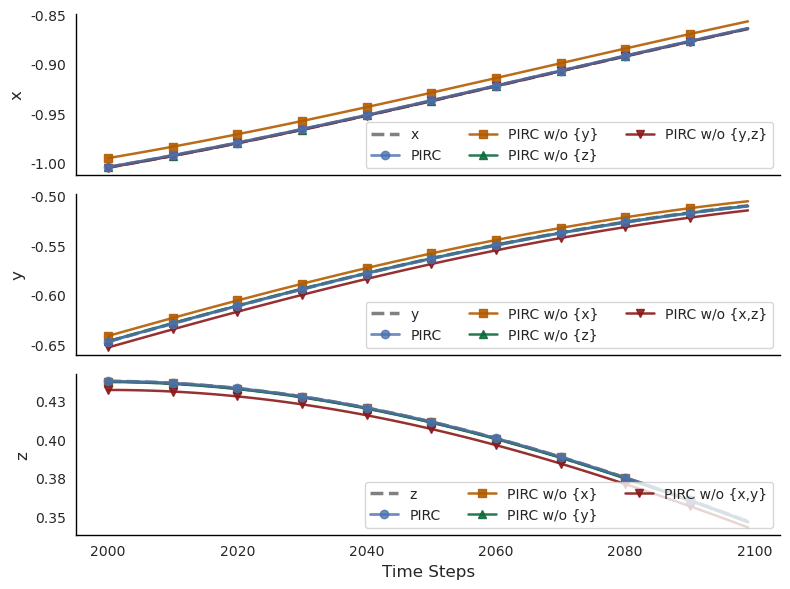

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

variable_num, time_steps = Y_test_predict[0, :, :N_test, 0].shape

variable_list = ['x', 'y', 'z']

intervention_dict = {
    'x': ["PIRC w/o {y}", "PIRC w/o {z}", "PIRC w/o {y,z}"],
    'y': ["PIRC w/o {x}", "PIRC w/o {z}", "PIRC w/o {x,z}"],
    'z': ["PIRC w/o {x}", "PIRC w/o {y}", "PIRC w/o {x,y}"]
}

t = np.arange(time_steps)

colors = [
    '#0b3c5d',  # 深蓝
    '#b35c00',  # 深橙
    '#0f6b3c',  # 深绿
    '#8b1a1a',  # 深红
    '#4b3f72',  # 深紫
    '#5a3e36',  # 深棕
    '#7a2e5c',  # 深粉紫
    '#3a3a3a',  # 深灰
    '#6b6b00',  # 橄榄深黄
    '#0e5f5f'   # 深青
]
markers = [
    'o','s','^','v','<','>','D','d','p','h','H','*','X','P'
]

# ======================
# 子图（关键）
# ======================
fig, axes = plt.subplots(variable_num, 1, figsize=(8, 6))

if variable_num == 1:
    axes = [axes]

# ======================
# 主循环
# ======================
for variable_id in range(variable_num):

    ax = axes[variable_id]
    var_name = variable_list[variable_id]

    # ===== 数据（完全保留你的写法）=====
    gt = Y_test[0, :, variable_id].detach().cpu().numpy()

    base = Y_test_predict[0, :, :N_test, 0].detach().cpu().numpy()
    base = base[variable_id, :]

    # ===== Ground Truth =====
    ax.plot(
        t, gt,
        linestyle='--',
        color='gray',
        linewidth=2.5,
        label=var_name
        # label='Ground Truth'
    )

    # ===== Baseline =====
    ax.plot(
        t, base,
        color='#4C72B0',
        marker=markers[0],
        markevery=10,
        linewidth=2,
        alpha=0.8,
        label='PIRC',
        zorder=4
    )

    # ===== 干预 =====
    for idx, label in enumerate(intervention_dict[var_name]):

        inter = Y_test_predict[3 + idx, :, :N_test, 0].detach().cpu().numpy()
        inter = inter[variable_id, :]

        ax.plot(
            t, inter,
            color=colors[idx+1],
            marker=markers[idx+1],
            markevery=10,
            linewidth=1.8,
            alpha=0.9,
            label=label
        )

        ax.grid(False)

    # # ===== Ground Truth =====
    # ax.plot(
    #     t, gt,
    #     linestyle='--',
    #     color='gray',
    #     linewidth=3,
    #     label=var_name
    #     # label='Ground Truth'
    # )

    # ===== 只最后一张图显示 legend =====
    # if variable_id == variable_num - 1:
    ax.legend(
        loc='lower right',
        # frameon=False,
        fontsize=10,
        ncol=3
    )

    # ===== 标签 =====
    ax.set_ylabel(var_name, fontsize=12)
    if variable_id == variable_num - 1:
        ax.set_xlabel("Time Steps", fontsize=12)
    else:
        ax.set_xlabel("")
        # ax.set_xticks(t)
    if variable_id == variable_num - 1:
        # ax.set_xticks(t)
        from matplotlib.ticker import FuncFormatter
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x + 2000)}"))
        # ax.tick_params(axis='x', labelsize=10)
    else:
        ax.set_xticks([])  # 或者 ax.set_xticklabels([])
        # ax.set_xticks(t)
        # ax.tick_params(axis='x', labelsize=10)
    # ===== 美化 =====
    # ax.grid(alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine in ['left', 'bottom']:
            ax.spines[spine].set_color('black')
            ax.spines[spine].set_linewidth(1)
    from matplotlib.ticker import FormatStrFormatter
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# ======================
# 紧凑布局
# ======================
# plt.subplots_adjust(hspace=0.5)
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'

plt.tight_layout()
plt.savefig(
    "pirc_timeseries.svg",   # 文件名（推荐 PDF/EPS 用于论文）
    dpi=1200,                # 分辨率
    bbox_inches='tight'     # 去掉多余白边
)

plt.show()

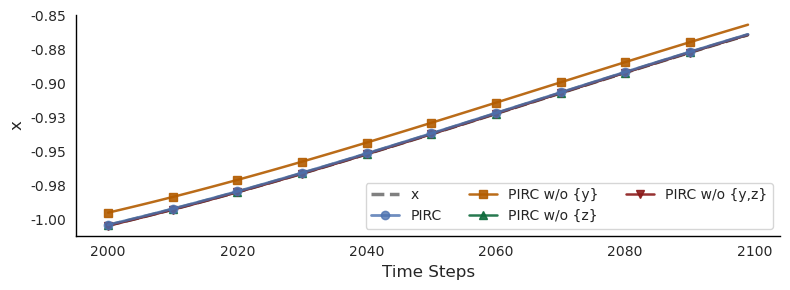

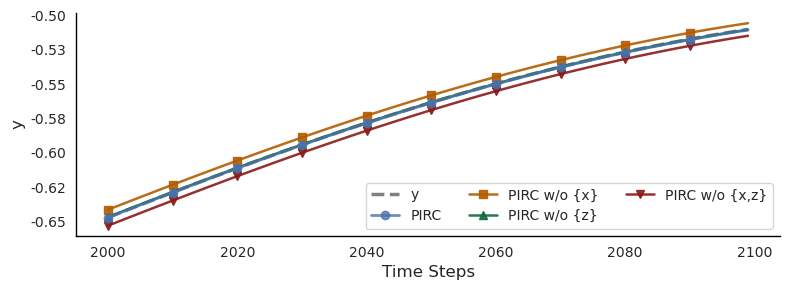

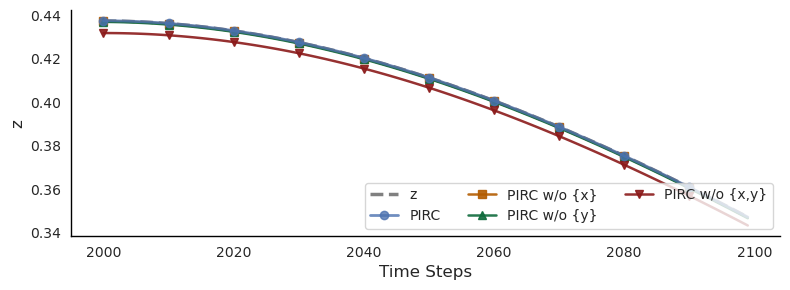

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FormatStrFormatter

variable_num, time_steps = Y_test_predict[0, :, :N_test, 0].shape

variable_list = ['x', 'y', 'z']

intervention_dict = {
    'x': ["PIRC w/o {y}", "PIRC w/o {z}", "PIRC w/o {y,z}"],
    'y': ["PIRC w/o {x}", "PIRC w/o {z}", "PIRC w/o {x,z}"],
    'z': ["PIRC w/o {x}", "PIRC w/o {y}", "PIRC w/o {x,y}"]
}

t = np.arange(time_steps)

colors = [
    '#0b3c5d',
    '#b35c00',
    '#0f6b3c',
    '#8b1a1a',
    '#4b3f72',
    '#5a3e36',
    '#7a2e5c',
    '#3a3a3a',
    '#6b6b00',
    '#0e5f5f'
]

markers = [
    'o','s','^','v','<','>','D','d','p','h','H','*','X','P'
]

# ==========================================
# 每个变量单独保存一张图
# ==========================================
for variable_id in range(variable_num):

    fig, ax = plt.subplots(figsize=(8, 3))

    var_name = variable_list[variable_id]

    gt = Y_test[0, :, variable_id].detach().cpu().numpy()

    base = Y_test_predict[0, :, :N_test, 0].detach().cpu().numpy()
    base = base[variable_id]

    # Ground Truth
    ax.plot(
        t, gt,
        '--',
        color='gray',
        linewidth=2.5,
        label=var_name
    )

    # Baseline
    ax.plot(
        t, base,
        color='#4C72B0',
        marker=markers[0],
        markevery=10,
        linewidth=2,
        alpha=0.8,
        label='PIRC',
        zorder=4
    )

    # Intervention
    for idx, label in enumerate(intervention_dict[var_name]):

        inter = Y_test_predict[3 + idx, :, :N_test, 0].detach().cpu().numpy()
        inter = inter[variable_id]

        ax.plot(
            t,
            inter,
            color=colors[idx + 1],
            marker=markers[idx + 1],
            markevery=10,
            linewidth=1.8,
            alpha=0.9,
            label=label
        )

    ax.legend(
        loc='lower right',
        fontsize=10,
        ncol=3
    )

    ax.set_ylabel(var_name, fontsize=12)
    ax.set_xlabel("Time Steps", fontsize=12)

    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f"{int(x + 2000)}")
    )

    ax.yaxis.set_major_formatter(
        FormatStrFormatter('%.2f')
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1)

    ax.grid(False)

    plt.tight_layout()
    import matplotlib.pyplot as plt

    import matplotlib as mpl

    mpl.rcParams['svg.fonttype'] = 'none'
    # ===========================
    # 保存 SVG
    # ===========================
    plt.savefig(
        f"{var_name}_timeseries.svg",
        format="svg",
        dpi=1000,
        bbox_inches="tight"
    )

    plt.show()

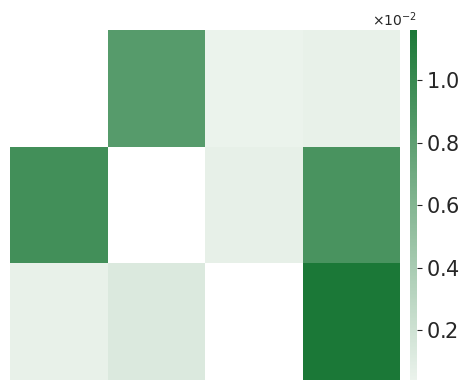

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

score_np = Score.detach().cpu().numpy()
B, E = score_np.shape

mask = np.eye(B, E, dtype=bool)

plt.figure(figsize=(5, 4))

ax = sns.heatmap(
    score_np,
    mask=mask,
    cmap = sns.light_palette("#1b7837", as_cmap=True),
    cbar=True,
    cbar_kws={
        "shrink": 1.0,
        "aspect": 50,   # 👈 控制细长程度（越大越细长）
        "pad": 0.02     # 👈 和图的间距
    },
    linewidths=0,        # ❌ 关网格
    xticklabels=False,   # ❌ 关 xtick
    yticklabels=False    # ❌ 关 ytick
)

# === 拿到 colorbar ===
cbar = ax.collections[0].colorbar

# === 1️⃣ 科学计数法 ===
import matplotlib.ticker as ticker
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))   # 超过这个范围才用科学计数法
cbar.ax.yaxis.set_major_formatter(formatter)

# === 2️⃣ 字体大小 ===
cbar.ax.tick_params(labelsize=15)

# === 3️⃣ 指数 (×10^x) 字体大小 ===
cbar.ax.yaxis.get_offset_text().set_size(10)

# ❌ 再保险：彻底关 ticks
ax.set_xticks([])
ax.set_yticks([])

# ❌ 去掉边框（更干净）
# for spine in ax.spines.values():
#     spine.set_visible(False)

# === 虚线对角线 ===
# n = min(B, E)
# ax.plot(
#     [0, n],
#     [0, n],
#     '--',
#     color='gray',
#     linewidth=1.2
# )

# === 每一行之间添加边框（不添加竖线）===
# for y in range(1, B):
#     ax.hlines(
#         y,
#         xmin=0,
#         xmax=E,
#         colors='black',
#         linewidth=1.2
#     )
# # === 外边框 ===
# ax.hlines([0, B], xmin=0, xmax=E, colors='black', linewidth=1.2)
# ax.vlines([0, E], ymin=0, ymax=B, colors='black', linewidth=1.2)

plt.tight_layout()
mpl.rcParams["svg.fonttype"] = "none"   # 文字保留为 text，不转 path
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "DejaVu Serif"
mpl.rcParams["mathtext.fontset"] = "stix"
plt.savefig(
    "Lorenz_heatmap_Green.svg",
    format="svg",
    bbox_inches=None,
    pad_inches=0.02
)
plt.show()

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.cluster import KMeans


def plot_kmeans_threshold_jitter(
    Score,
    save_path="KMeans_threshold_jitter.png",
    remove_diag=True,
    random_state=0,
    threshold_range="between_centers",  # or "quantile"
):
    if torch.is_tensor(Score):
        score = Score.detach().cpu().numpy()
    else:
        score = np.asarray(Score)
    B, E = score.shape
    mask = np.ones_like(score, dtype=bool)
    if remove_diag:
        d = min(B, E)
        mask[np.arange(d), np.arange(d)] = False
    x = score[mask].reshape(-1, 1)
    km = KMeans(n_clusters=2, random_state=random_state, n_init=20)
    labels = km.fit_predict(x)
    centers = km.cluster_centers_.flatten()
    low_id, high_id = np.argsort(centers)
    no_causal = labels == low_id
    causal = labels == high_id
    c_low, c_high = np.sort(centers)
    threshold = (c_low + c_high) / 2
    # 阴影阈值范围
    range_left = np.percentile(x[no_causal], 100)
    range_right = np.percentile(x[causal], 0)
    rng = np.random.default_rng(random_state)
    jitter = rng.normal(0, 1.25, size=len(x))
    x = x.flatten()
    fig, ax = plt.subplots(figsize=(5, 4), dpi=1200)
    ax.axvspan(
        range_left+2e-5,
        range_right-2e-5,
        color="#f4a340",
        alpha=0.18,
        linestyle="--",
        linewidth=1.5,
        edgecolor="#f4a340",
        label="Feasible threshold range"
    )
    ax.scatter(
        x[no_causal],
        jitter[no_causal],
        s=60,
        facecolors="white",
        edgecolors="0.72",
        linewidths=1.4,
        alpha=0.95,
        label="No causal effect"
    )
    ax.scatter(
        x[causal],
        jitter[causal],
        s=60,
        color="#1f77b4",
        edgecolors="#1f77b4",
        linewidths=0.8,
        alpha=0.95,
        label="Causal effect exists"
    )
    ax.axvline(
        threshold,
        color="red",
        linestyle="--",
        linewidth=2.2,
        label="K-means threshold"
    )
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    ax.xaxis.set_major_formatter(formatter)
    ax.xaxis.get_offset_text().set_size(13)

    ax.set_xlabel("CI", fontsize=16)
    ax.grid(False)
    ax.set_yticks([])
    ax.tick_params(axis="both", labelsize=13, width=1.3, length=6)

    for spine in ax.spines.values():
        spine.set_linewidth(1.3)

    handles, labels_ = ax.get_legend_handles_labels()
    order = [
        labels_.index("No causal effect"),
        labels_.index("Causal effect exists"),
        labels_.index("K-means threshold"),
        labels_.index("Feasible threshold range"),
    ]
    ax.legend(
        [handles[i] for i in order],
        [labels_[i] for i in order],
        fontsize=12,
        frameon=True,
        loc="upper right"
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine in ['left', 'bottom']:
            ax.spines[spine].set_color('black')
            ax.spines[spine].set_linewidth(1)
    from matplotlib.ticker import FormatStrFormatter
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    plt.tight_layout()
    mpl.rcParams['svg.fonttype'] = 'none'
    plt.savefig(save_path, dpi=1000, bbox_inches="tight")
    plt.show()

    print("Cluster centers:", np.sort(centers))
    print(f"K-means threshold: {threshold:.6e}")
    print(f"Feasible threshold range: [{range_left:.6e}, {range_right:.6e}]")

    return threshold, (range_left, range_right), labels

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fe2d4e973a0>
Traceback (most recent call last):
  File "/home/caoren/anaconda3/envs/pytorch/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/caoren/anaconda3/envs/pytorch/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/caoren/anaconda3/envs/pytorch/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/caoren/anaconda3/envs/pytorch/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Threadpool

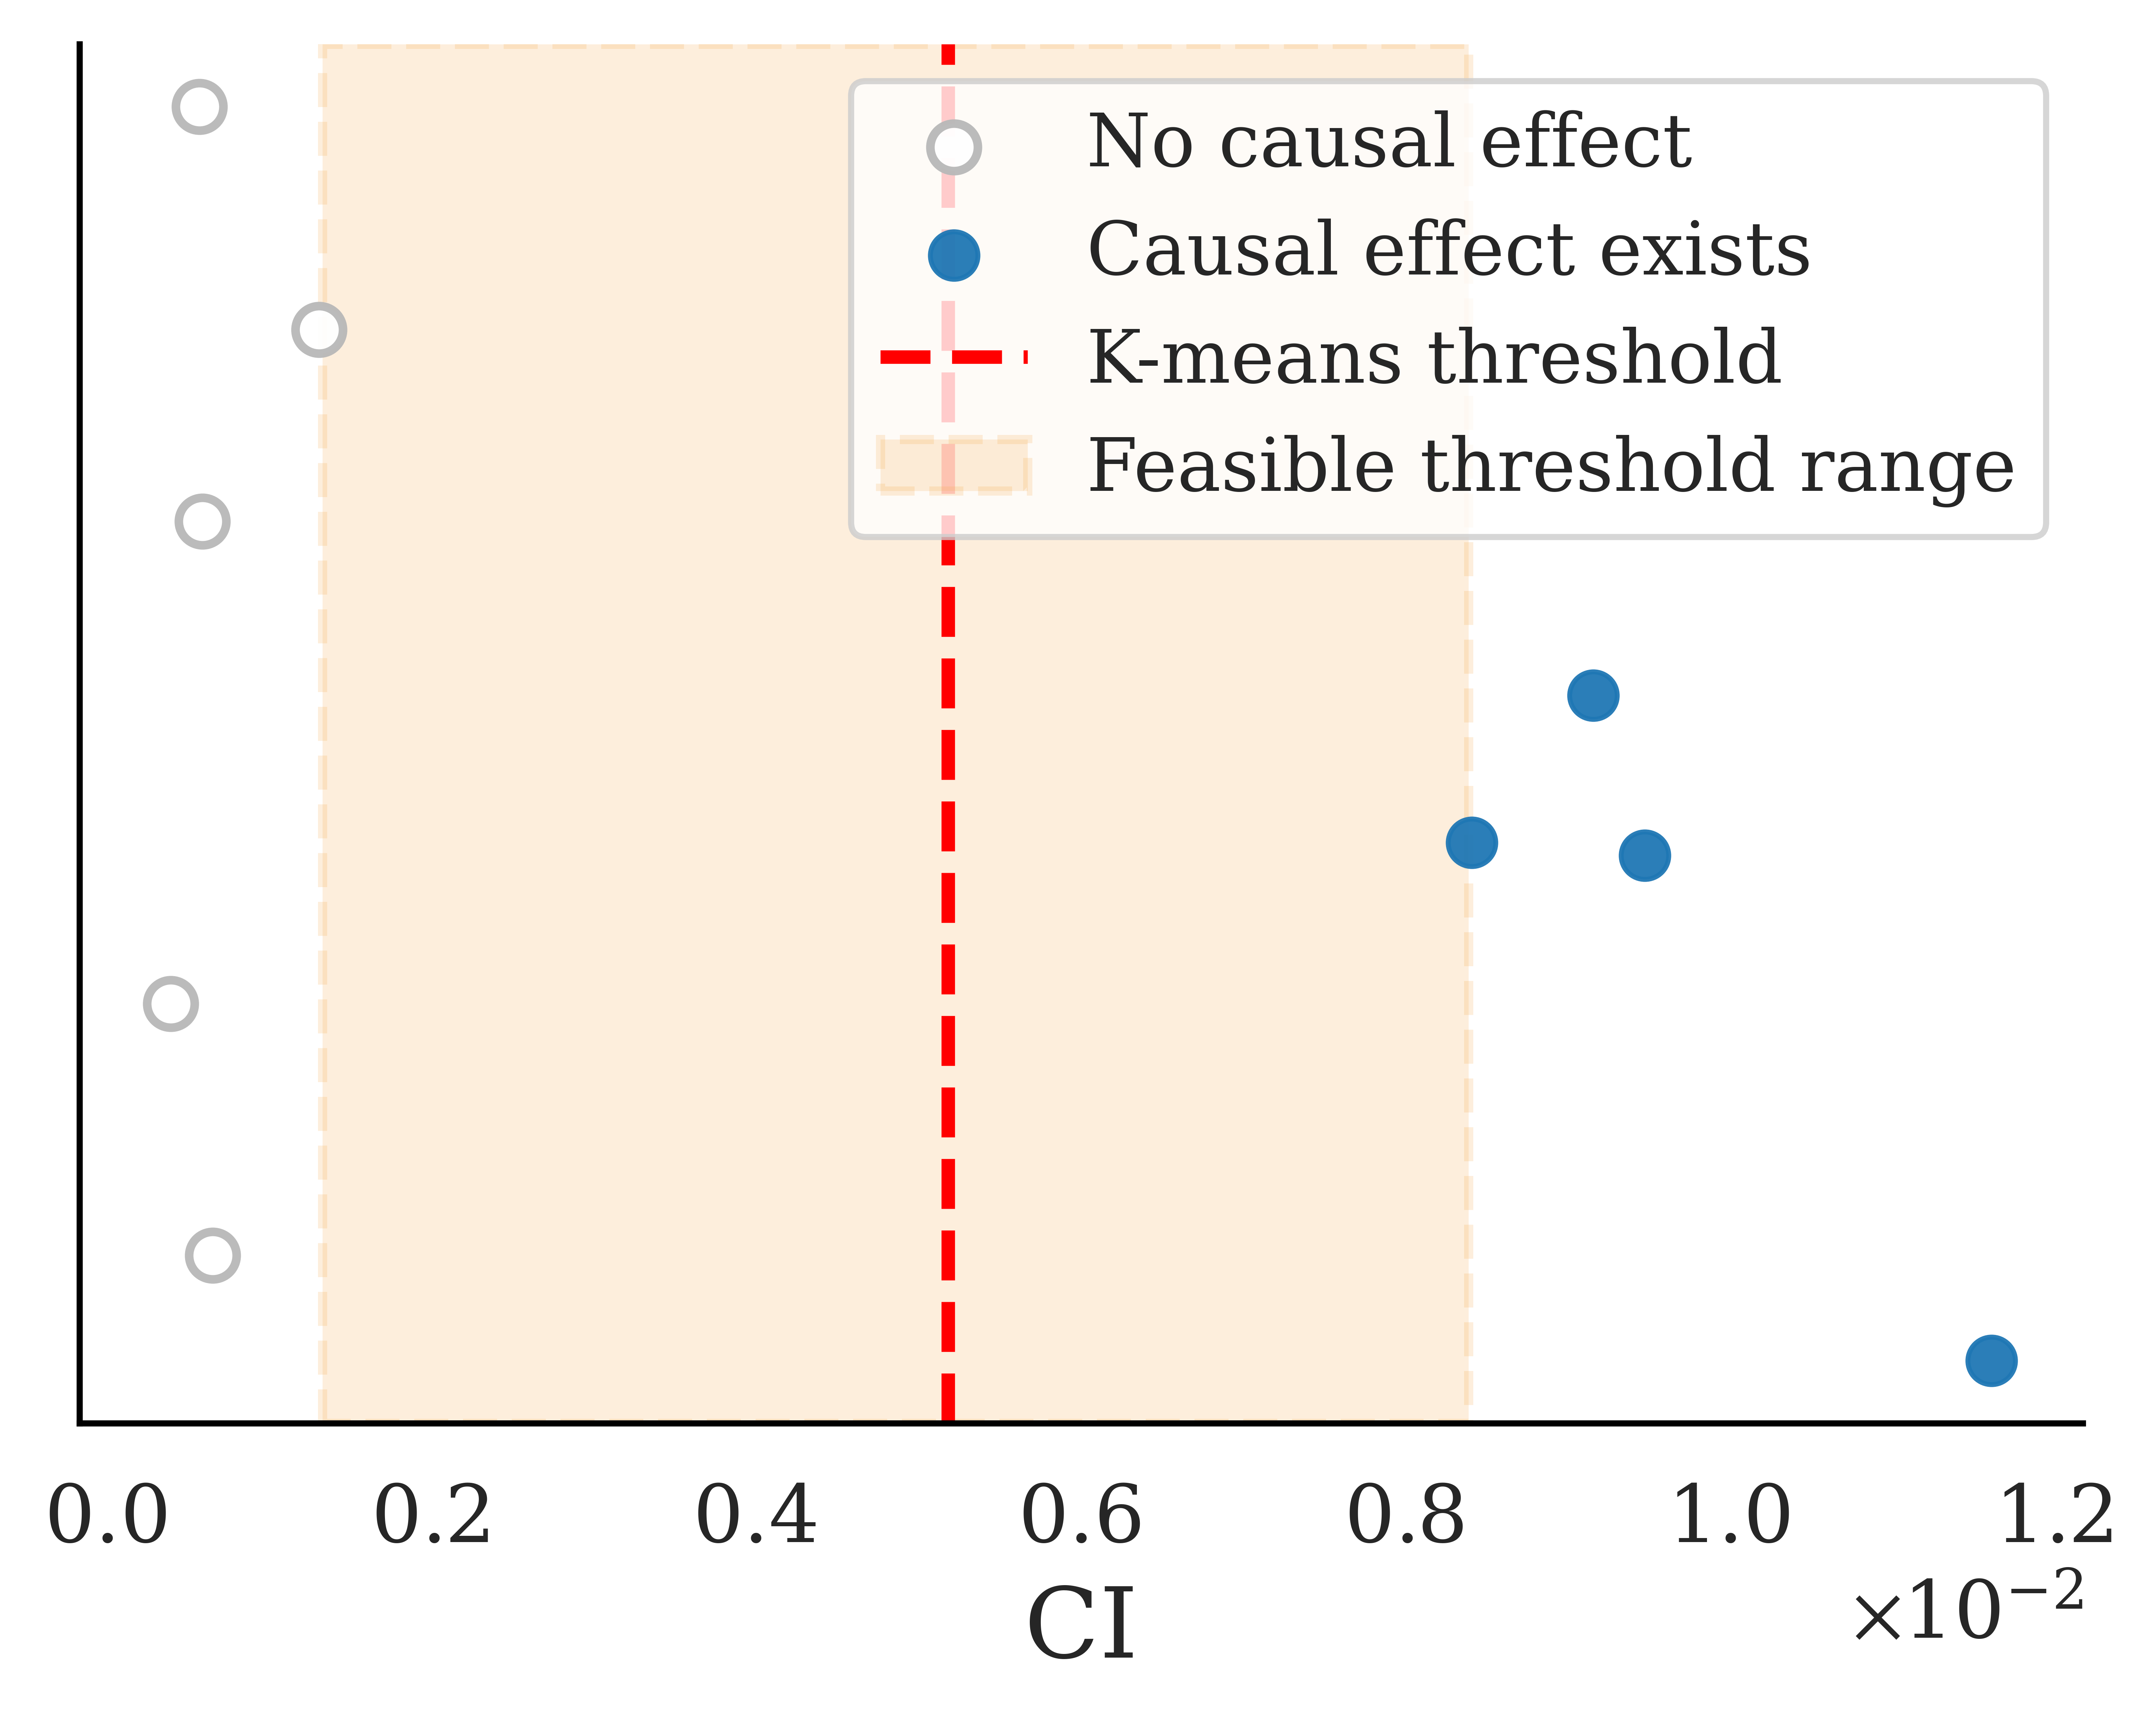

Cluster centers: [0.00071206 0.00967258]
K-means threshold: 5.192317e-03
Feasible threshold range: [1.316929e-03, 8.418843e-03]


In [18]:
threshold, threshold_range, labels = plot_kmeans_threshold_jitter(
    Score,
    save_path="Lorenz_KMeans_Jitter.svg"
)